# Step 1 — Data Preprocessing and Preliminary Analysis

## 1. Objective and Context

The objective of this preprocessing phase is to prepare molecular dynamics simulation data for subsequent deep learning modeling.

The datasets describe the temporal evolution of a protein system through atomic coordinates, forces, and velocities.

The preprocessing aims to:
- verify data integrity and consistency,
- remove redundant or non-informative variables (timestamp),
- normalize the data to ensure numerical stability during training,
- preserve the physical meaning of the variables.

This step corresponds to **Step 1 (Import the data and check for errors and inconsistencies)** of the project workflow.

---

## 2. Datasets Description

Three datasets are considered:

| Dataset | Description | Raw Shape |
|---------|-------------|-----------|
| **coordinates.csv** | Atomic positions (x, y, z) over time | (50001, 415) |
| **forces.csv** | Atomic forces (x, y, z) over time | (50001, 415) |
| **velocity.csv** | Atomic velocities (x, y, z) over time | (50001, 415) |

Each dataset contains:
- 50,001 time steps
- 1 timestamp column (to be removed)
- 414 physical features (138 atoms × 3 spatial components)

---

## 3. Data Loading and Format Handling

The three datasets required different parsing strategies due to format inconsistencies:

| Dataset | Separator | Additional Issue |
|---------|-----------|------------------|
| coordinates.csv | `;` | None |
| forces.csv | `\t` (tab) | Spurious quote characters (`"`) |
| velocity.csv | `\t` (tab) | Spurious quote characters (`"`) |

A robust `read_dataset()` function was implemented to:
- automatically detect the correct separator,
- remove spurious quote characters from forces and velocity files,
- ensure consistent parsing across all datasets.

---

## 4. Timestamp Removal

All three datasets contain a timestamp column (column 0) with values starting at 0.000 and incrementing by Δt ≈ 0.002.

The timestamp was verified to be:
- strictly monotonic (always increasing),
- constant step size (Δt = 0.002),
- identical across all three datasets.

Since the temporal ordering is already encoded by the sequence index, the timestamp column was **removed from all datasets** before training. The timestamp was saved separately for potential analysis or visualization.

**Final shape after timestamp removal: (50001, 414) for all datasets.**

---

## 5. Data Cleaning

All datasets were checked for missing or invalid values:

| Check | Result |
|-------|--------|
| Missing values (NaN) | None found |
| Invalid entries | None found |
| Interpolation required | No |

This confirms the integrity of the molecular dynamics simulation output.

---

## 6. Feature Scaling

All physical variables were standardized using **StandardScaler** (Z-score normalization), applied independently to each dataset.

The transformation enforces:
- mean ≈ 0
- standard deviation ≈ 1

**Quality check results:**

| Dataset | Scaled Mean | Scaled Std | Status |
|---------|-------------|------------|--------|
| coordinates | ≈ 0 | ≈ 1 | ✓ |
| forces | ≈ 0 | ≈ 1 | ✓ |
| velocity | ≈ 0 | ≈ 1 | ✓ |

Feature scaling is essential to:
- ensure numerical stability during training,
- prevent dominance of variables with larger physical scales,
- allow fair comparison between different physical quantities.

The fitted scalers were saved as `.pkl` files for inverse transformation of predictions.

---

## 7. Distribution Analysis and Physical Interpretation

Standardization rescales the data but does not change the underlying distribution shape. The resulting distributions reflect the physical nature of each variable.

### 7.1 Coordinates (Non-Gaussian)
The distribution of atomic coordinates is **non-gaussian and asymmetric**, with a pronounced peak toward higher values. This is exactly what we expect: protein atoms are not free to move anywhere in space, but are **constrained by molecular structure** (covalent bonds, bond angles, protein folding). The peak indicates that many atoms occupy a preferred spatial region, consistent with the 3D conformation of the protein.

### 7.2 Forces (Quasi-Gaussian)
The distribution of forces is **approximately gaussian and symmetric**, centered at zero, but exhibits **heavier tails** compared to an ideal Gaussian. This reflects the physics of molecular interactions: most of the time forces are moderate, but occasionally **force spikes** occur due to close collisions, intense electrostatic repulsions, or geometric constraints. Heavy tails are typical of non-linear potentials (Lennard-Jones, Coulomb).

### 7.3 Velocity (Gaussian)
The distribution of velocities is **gaussian and symmetric**, perfectly centered at zero. This is the expected result from statistical mechanics: in an MD simulation at thermal equilibrium, the components of atomic velocities follow the **Maxwell-Boltzmann distribution**, which for each Cartesian component (vx, vy, vz) is a Gaussian. This confirms that the simulation has reached thermodynamic equilibrium.

### Summary Table

| Dataset | Distribution Type | Physical Interpretation |
|---------|-------------------|------------------------|
| Velocity | Gaussian | Maxwell-Boltzmann equilibrium statistics |
| Forces | Quasi-Gaussian | Non-linear interactions with heavy tails |
| Coordinates | Non-Gaussian | Structural and conformational constraints |

---

## 8. Output Artifacts

All preprocessing artifacts were saved in the `processed_step1/` directory:

| File | Description |
|------|-------------|
| `{name}_clean.csv` | Cleaned data (timestamp removed) |
| `{name}_scaled.csv` | Standardized data (Z-score) |
| `{name}_time.csv` | Extracted timestamp (for reference) |
| `scaler_{name}.pkl` | Fitted StandardScaler object |
| `meta_{name}.json` | Metadata (shape, statistics, parameters) |

---

## 9. Quality Assessment Summary

| Requirement | Status |
|-------------|--------|
| Temporal consistency verified | ✓ |
| No missing or corrupted data | ✓ |
| Timestamp removed from all datasets | ✓ |
| All datasets aligned (50001 × 414) | ✓ |
| Feature scaling applied | ✓ |
| Physical meaning preserved | ✓ |
| Scalers saved for reproducibility | ✓ |

---

## 10. Conclusion

This preprocessing step successfully prepares the molecular dynamics datasets for deep learning applications.

Key accomplishments:
- Resolved format inconsistencies across the three source files
- Removed timestamp column uniformly from all datasets
- Verified physical consistency of the distributions
- Produced aligned, scaled datasets ready for model training

The processed datasets and corresponding scalers are now ready for **Step 2: Dataset Construction** (dimensionality reduction and windowing).

## Random Seed Configuration

To ensure reproducibility of all experiments, random seeds are fixed at the beginning of the pipeline.

| Library | Seed Value |
|---------|------------|
| NumPy | 42 |
| Python random | 42 |

This guarantees that any random operations (e.g., sampling for visualization) produce consistent results across different runs.

In [2]:
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## Preprocessing Functions Definition

This cell defines the core functions for the preprocessing pipeline:

### `read_dataset(path)`
Handles the different file formats present in the source data:
- First attempts parsing with semicolon (`;`) separator (used by `coordinates.csv`)
- If that fails, reads the file as text and removes spurious quote characters (`"`)
- Then attempts tab (`\t`) or whitespace separation (used by `forces.csv` and `velocity.csv`)

This robust approach ensures consistent loading regardless of format inconsistencies.

### `summarize_time(series)`
Analyzes the timestamp column to verify temporal consistency:
- Checks if values are numeric and strictly monotonic
- Computes the time step (Δt) statistics (median, min, max)
- Returns a dictionary with temporal metadata for quality assessment

### `clean_and_scale(df)`
Performs data cleaning and standardization:
- Converts all values to numeric type
- **Removes column 0 (timestamp) from all datasets**
- Handles missing values via linear interpolation (if any)
- Applies **StandardScaler** (Z-score normalization)
- Computes descriptive statistics before and after scaling

### `save_artifacts(base_name, result, meta)`
Saves all preprocessing outputs to the `processed_step1/` directory:
- `{name}_clean.csv`: Cleaned features (timestamp removed)
- `{name}_scaled.csv`: Standardized features
- `{name}_time.csv`: Extracted timestamp
- `scaler_{name}.pkl`: Fitted scaler (for inverse transform)
- `meta_{name}.json`: Metadata and statistics

In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

INPUT_FILES = ["coordinates.csv", "forces.csv", "velocity.csv"]
OUT_DIR = "processed_step1"
os.makedirs(OUT_DIR, exist_ok=True)

def read_dataset(path):
    """
    Reads the dataset handling different formats.
    Removes spurious quotes and identifies the correct separator.
    """
    # First try with semicolon separator
    df1 = pd.read_csv(path, sep=";", header=None, engine="python")
    if df1.shape[1] > 1:
        return df1, ";"
    
    # Otherwise read as text and clean quotes
    with open(path, 'r') as f:
        lines = f.readlines()
    
    # Remove quotes from each line
    cleaned_lines = [line.replace('"', '').strip() for line in lines]
    
    # Rebuild as dataframe using tab or whitespace
    from io import StringIO
    cleaned_text = '\n'.join(cleaned_lines)
    
    # Try with tab
    df2 = pd.read_csv(StringIO(cleaned_text), sep="\t", header=None, engine="python")
    if df2.shape[1] > 1:
        return df2, "\\t (cleaned)"
    
    # Otherwise whitespace
    df3 = pd.read_csv(StringIO(cleaned_text), sep=r"\s+", header=None, engine="python")
    return df3, "whitespace (cleaned)"


def summarize_time(series):
    t = pd.to_numeric(series, errors="coerce")
    ok_numeric = float(t.isna().mean()) == 0.0
    mono = bool(t.is_monotonic_increasing) if ok_numeric else False
    head = t.head(5).tolist() if ok_numeric else series.head(5).tolist()
    tail = t.tail(5).tolist() if ok_numeric else series.tail(5).tolist()
    dt = np.diff(t.values) if ok_numeric and len(t) > 1 else np.array([])
    dt_median = float(np.median(dt)) if dt.size > 0 else None
    dt_min = float(np.min(dt)) if dt.size > 0 else None
    dt_max = float(np.max(dt)) if dt.size > 0 else None
    return {
        "time_numeric": bool(ok_numeric),
        "time_monotonic": bool(mono),
        "time_head": head,
        "time_tail": tail,
        "dt_median": dt_median,
        "dt_min": dt_min,
        "dt_max": dt_max
    }

def clean_and_scale(df):
    """
    Cleans and scales the dataframe.
    NOTE: Column 0 (timestamp) is ALWAYS removed for all datasets.
    """
    df_num = df.apply(pd.to_numeric, errors="coerce")
    df_num = df_num.dropna(axis=1, how="all")

    # Extract timestamp (column 0) and features (columns 1:)
    time = df_num.iloc[:, 0].copy()
    X = df_num.iloc[:, 1:].copy()

    nan_before = int(X.isna().sum().sum())
    if nan_before > 0:
        X = X.interpolate(method="linear", limit_direction="both")

    X = X.dropna(axis=1, how="all")
    nan_after = int(X.isna().sum().sum())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)

    X_clean = X.reset_index(drop=True)
    X_scaled_df = pd.DataFrame(X_scaled, columns=[str(c) for c in X_clean.columns])

    stats_clean = X_clean.describe().T[["mean", "std", "min", "max"]]
    stats_scaled = X_scaled_df.describe().T[["mean", "std", "min", "max"]]

    return {
        "X_clean": X_clean,
        "X_scaled": X_scaled_df,
        "time": time,
        "scaler": scaler,
        "nan_before": nan_before,
        "nan_after": nan_after,
        "clean_stats": {
            "mean_global": float(stats_clean["mean"].mean()),
            "std_global": float(stats_clean["std"].mean()),
            "min_global": float(stats_clean["min"].min()),
            "max_global": float(stats_clean["max"].max())
        },
        "scaled_stats": {
            "mean_global": float(stats_scaled["mean"].mean()),
            "std_global": float(stats_scaled["std"].mean()),
            "min_global": float(stats_scaled["min"].min()),
            "max_global": float(stats_scaled["max"].max())
        }
    }

def save_artifacts(base_name, result, meta):
    clean_csv = os.path.join(OUT_DIR, f"{base_name}_clean.csv")
    scaled_csv = os.path.join(OUT_DIR, f"{base_name}_scaled.csv")
    scaler_pkl = os.path.join(OUT_DIR, f"scaler_{base_name}.pkl")
    meta_json = os.path.join(OUT_DIR, f"meta_{base_name}.json")
    time_csv = os.path.join(OUT_DIR, f"{base_name}_time.csv")

    result["X_clean"].to_csv(clean_csv, index=False)
    result["X_scaled"].to_csv(scaled_csv, index=False)
    joblib.dump(result["scaler"], scaler_pkl)

    if result["time"] is not None:
        pd.Series(result["time"]).to_csv(time_csv, index=False, header=False)

    with open(meta_json, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    return {
        "clean_csv": clean_csv,
        "scaled_csv": scaled_csv,
        "scaler_pkl": scaler_pkl,
        "meta_json": meta_json,
        "time_csv": time_csv if result["time"] is not None else None
    }

## File Structure Diagnostic

This cell performs a detailed inspection of the raw file structure before preprocessing.

### Purpose

Verify that data loading and quote cleaning worked correctly by examining:
- **Separator detected**: Confirms correct parsing strategy was applied
- **Shape**: Raw dimensions of each dataset
- **Column 0**: Should contain timestamp values (0.000, 0.002, 0.004, ...)
- **Column 1**: First actual feature (should be numeric physical data)
- **Last column**: Verifies no trailing artifacts or quote characters
- **NaN columns**: Identifies any completely empty columns
- **Data type**: Confirms numeric parsing succeeded

### Expected Results

| Dataset | Separator | Column 0 (timestamp) | Issues |
|---------|-----------|---------------------|--------|
| coordinates.csv | `;` | [0.0, 0.002, ...] | None |
| forces.csv | `\t (cleaned)` | [0.0, 0.002, ...] | Quotes removed |
| velocity.csv | `\t (cleaned)` | [0.0, 0.002, ...] | Quotes removed |

This diagnostic confirms that the `read_dataset()` function correctly handles format inconsistencies across the source files.

In [2]:
print("=== FILE STRUCTURE DIAGNOSTIC ===\n")

for f in INPUT_FILES:
    df, sep = read_dataset(f)
    print(f"FILE: {f}")
    print(f"  Separator: {sep}")
    print(f"  Shape: {df.shape}")
    print(f"  Column 0 (first 5 rows): {df.iloc[:5, 0].tolist()}")
    print(f"  Column 1 (first 5 rows): {df.iloc[:5, 1].tolist()}")
    print(f"  Last column (first 5 rows): {df.iloc[:5, -1].tolist()}")
    
    nan_cols = df.columns[df.isna().all()].tolist()
    print(f"  Fully NaN columns: {nan_cols}")
    
    print(f"  Column 0 dtype: {df.iloc[:, 0].dtype}")
    print()

=== FILE STRUCTURE DIAGNOSTIC ===

FILE: coordinates.csv
  Separator: ;
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [56.398, 56.3992, 56.3999, 56.4001, 56.4001]
  Last column (first 5 rows): [52.421, 52.4215, 52.4222, 52.4229, 52.4236]
  Fully NaN columns: []
  Column 0 dtype: float64

FILE: forces.csv
  Separator: \t (cleaned)
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [-1145.43, -1888.0, -1840.93, -1041.78, 97.5775]
  Last column (first 5 rows): [847.998, 625.43, 258.009, -139.416, -441.616]
  Fully NaN columns: []
  Column 0 dtype: float64

FILE: velocity.csv
  Separator: \t (cleaned)
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [0.7728, 0.612864, 0.352195, 0.111483, -0.0193876]
  Last column (first 5 rows): [0.1593, 0.265599, 0.332929, 0.36518, 0.347753]
  Fully NaN columns: []
  Column 

## Execute Preprocessing Pipeline

This cell runs the complete preprocessing pipeline on all three datasets.

### Processing Steps (for each dataset)

1. **File Validation**: Check that input files exist
2. **Data Loading**: Read dataset using the robust `read_dataset()` function
3. **Timestamp Analysis**: Extract temporal metadata from column 0
4. **Cleaning & Scaling**: Remove timestamp, handle NaN values, apply StandardScaler
5. **Save Artifacts**: Export all outputs to `processed_step1/` directory
6. **Logging**: Print detailed summary for each dataset

### Output Verification

For each dataset, the pipeline verifies and reports:
- **Raw Shape**: Original dimensions (should be 50001 × 415)
- **Final Shape**: After timestamp removal (should be 50001 × 414)
- **Time Monotonic**: Confirms timestamp is strictly increasing
- **NaN Count**: Before and after cleaning (expected: 0)
- **Scaled Statistics**: Mean ≈ 0 and Std ≈ 1 confirms correct standardization

### Summary DataFrame

The final `summary_df` table collects all metadata for quick comparison across datasets, enabling automated quality checks in the next cell.

In [ ]:
for f in INPUT_FILES:
    if not os.path.exists(f):
        raise FileNotFoundError(f"File not found: {f}")

rows = []

for f in INPUT_FILES:
    base = os.path.splitext(os.path.basename(f))[0].lower()
    df, sep_used = read_dataset(f)

    # Timestamp is ALWAYS in column 0 for all datasets
    time_info = summarize_time(df.iloc[:, 0])

    res = clean_and_scale(df)  # Always removes column 0 (timestamp)

    meta = {
        "file": f,
        "base_name": base,
        "separator_used": sep_used,
        "raw_shape": [int(df.shape[0]), int(df.shape[1])],
        "final_shape": [int(res["X_scaled"].shape[0]), int(res["X_scaled"].shape[1])],
        "time_info": time_info,
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_stats": res["clean_stats"],
        "scaled_stats": res["scaled_stats"]
    }

    paths = save_artifacts(base, res, meta)

    print("\n" + "=" * 80)
    print("DATASET:", f)
    print("SEP:", sep_used)
    print("RAW SHAPE:", meta["raw_shape"])
    print("FINAL SHAPE (after timestamp removal):", meta["final_shape"])
    print("TIME MONOTONIC:", time_info["time_monotonic"])
    print("DT MEDIAN:", time_info["dt_median"])
    print("NaN BEFORE:", int(res["nan_before"]))
    print("NaN AFTER:", int(res["nan_after"]))
    print("CLEAN RANGE:", res["clean_stats"]["min_global"], res["clean_stats"]["max_global"])
    print("SCALED MEAN/STD:", res["scaled_stats"]["mean_global"], res["scaled_stats"]["std_global"])
    print("OUT CLEAN:", paths["clean_csv"])
    print("OUT SCALED:", paths["scaled_csv"])
    print("OUT SCALER:", paths["scaler_pkl"])
    print("OUT META:", paths["meta_json"])
    print("OUT TIME:", paths["time_csv"])

    rows.append({
        "dataset": f,
        "sep": sep_used,
        "raw_shape": meta["raw_shape"],
        "final_shape": meta["final_shape"],
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_min": res["clean_stats"]["min_global"],
        "clean_max": res["clean_stats"]["max_global"],
        "scaled_mean_global": res["scaled_stats"]["mean_global"],
        "scaled_std_global": res["scaled_stats"]["std_global"],
        "clean_csv": paths["clean_csv"],
        "scaled_csv": paths["scaled_csv"],
        "scaler_pkl": paths["scaler_pkl"]
    })

summary_df = pd.DataFrame(rows)
summary_df


DATASET: coordinates.csv
SEP: ;
RAW SHAPE: [50001, 415]
FINAL SHAPE (dopo rimozione timestamp): [50001, 414]
TIME MONOTONIC: True
DT MEDIAN: 0.0019999999999997797
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: 20.6903 57.0394
SCALED MEAN/STD: -3.0260963662181073e-17 1.0000099999500005
OUT CLEAN: processed_step1\coordinates_clean.csv
OUT SCALED: processed_step1\coordinates_scaled.csv
OUT SCALER: processed_step1\scaler_coordinates.pkl
OUT META: processed_step1\meta_coordinates.json
OUT TIME: processed_step1\coordinates_time.csv

DATASET: forces.csv
SEP: \t (cleaned)
RAW SHAPE: [50001, 415]
FINAL SHAPE (dopo rimozione timestamp): [50001, 414]
TIME MONOTONIC: True
DT MEDIAN: 0.0019999999999997797
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: -6772.97 6400.45
SCALED MEAN/STD: 2.0614337555998873e-19 1.0000099999500005
OUT CLEAN: processed_step1\forces_clean.csv
OUT SCALED: processed_step1\forces_scaled.csv
OUT SCALER: processed_step1\scaler_forces.pkl
OUT META: processed_step1\meta_forces.json
OUT TIME:

,dataset,sep,raw_shape,final_shape,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl
0,coordinates.csv,;,"[50001, 415]","[50001, 414]",0,0,20.69030,57.03940,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl
1,forces.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-6772.97000,6400.45000,2.061434e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl
2,velocity.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-8.77941,7.76788,7.320246e-19,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl


## Outlier Analysis

Before confirming that Z-score normalization is appropriate, we analyze the cleaned (but not yet scaled) data for extreme outliers. This analysis is performed on the original value ranges to determine if StandardScaler is suitable or if a more robust method would be needed.

We examine how many values fall beyond typical thresholds, calculated using the mean and standard deviation of each feature.

In [4]:
print("=== OUTLIER ANALYSIS (on cleaned data) ===\n")

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    
    # Calculate z-scores manually to find outliers
    mean = df.mean()
    std = df.std()
    z_scores = (df - mean) / std
    
    total = df.size
    
    # Count values beyond thresholds
    beyond_3 = (z_scores.abs() > 3).sum().sum()
    beyond_4 = (z_scores.abs() > 4).sum().sum()
    beyond_5 = (z_scores.abs() > 5).sum().sum()
    
    print(f"{name}:")
    print(f"  Total values: {total:,}")
    print(f"  Beyond ±3σ: {beyond_3:,} ({100*beyond_3/total:.4f}%)")
    print(f"  Beyond ±4σ: {beyond_4:,} ({100*beyond_4/total:.4f}%)")
    print(f"  Beyond ±5σ: {beyond_5:,} ({100*beyond_5/total:.4f}%)")
    
    if beyond_5 / total < 0.001:
        print(f"  No extreme outliers detected")
    else:
        print(f"  Significant outliers detected")
    print()

=== OUTLIER ANALYSIS (on cleaned data) ===

coordinates:
  Total values: 20,700,414
  Beyond ±3σ: 0 (0.0000%)
  Beyond ±4σ: 0 (0.0000%)
  Beyond ±5σ: 0 (0.0000%)
  No extreme outliers detected

forces:
  Total values: 20,700,414
  Beyond ±3σ: 118,453 (0.5722%)
  Beyond ±4σ: 10,640 (0.0514%)
  Beyond ±5σ: 961 (0.0046%)
  No extreme outliers detected

velocity:
  Total values: 20,700,414
  Beyond ±3σ: 80,058 (0.3867%)
  Beyond ±4σ: 4,406 (0.0213%)
  Beyond ±5σ: 241 (0.0012%)
  No extreme outliers detected



## Preprocessing Quality Check

This cell performs automated validation of the preprocessing results.

### Validation Criteria

| Check | Condition | Purpose |
|-------|-----------|---------|
| `ok_mean` | \|mean\| < 0.05 | Confirms data is centered near zero |
| `ok_std` | \|std - 1.0\| < 0.05 | Confirms unit variance normalization |
| `ok_nan` | NaN count = 0 | Confirms no missing values remain |
| `preprocessing_ok` | All checks pass | Global quality flag |

### Expected Results

All three datasets should show `True` for all checks, confirming that:
- StandardScaler was applied correctly
- No data corruption occurred during processing
- Datasets are ready for model training

If any check fails, the preprocessing pipeline should be investigated before proceeding to Step 2.

In [14]:
summary_df["ok_mean"] = summary_df["scaled_mean_global"].abs() < 0.05
summary_df["ok_std"] = (summary_df["scaled_std_global"] - 1.0).abs() < 0.05
summary_df["ok_nan"] = summary_df["nan_after"] == 0
summary_df["preprocessing_ok"] = summary_df["ok_mean"] & summary_df["ok_std"] & summary_df["ok_nan"]
summary_df


,dataset,sep,raw_shape,final_shape,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl,ok_mean,ok_std,ok_nan,preprocessing_ok
0,coordinates.csv,;,"[50001, 415]","[50001, 414]",0,0,20.69030,57.03940,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl,True,True,True,True
1,forces.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-6772.97000,6400.45000,2.061434e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl,True,True,True,True
2,velocity.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-8.77941,7.76788,7.320246e-19,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl,True,True,True,True


## Output Shape Verification

This cell performs a final check to confirm that all processed datasets have the expected dimensions.

### Expected Output

All three datasets should have identical shapes:

| Dataset | Expected Shape |
|---------|---------------|
| coordinates | (50001, 414) |
| forces | (50001, 414) |
| velocity | (50001, 414) |

Where:
- **50001** = number of timesteps in the MD simulation
- **414** = number of features (138 atoms × 3 spatial components)

This confirms that the timestamp column was correctly removed from all datasets and that they are now aligned for subsequent concatenation and model training.

In [8]:
import pandas as pd

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    print(name, df.shape)


coordinates (50001, 414)
forces (50001, 414)
velocity (50001, 414)


---
---
---

## Timestamp Consistency Verification

This cell visualizes the extracted timestamp to verify temporal consistency of the MD simulation.

### Purpose

Before using the data for deep learning, it is essential to verify that the timestamp:
- Is **monotonically increasing** (no jumps backward in time)
- Has a **constant time step** (uniform sampling rate)

### Expected Result

The plot should show a **straight diagonal line**, indicating:
- Linear time progression from t=0 to t≈4 (for the first 2000 samples)
- Constant step size Δt ≈ 0.002 between consecutive frames

This confirms the temporal coherence of the molecular dynamics simulation and validates that the timestamp was correctly extracted during preprocessing.

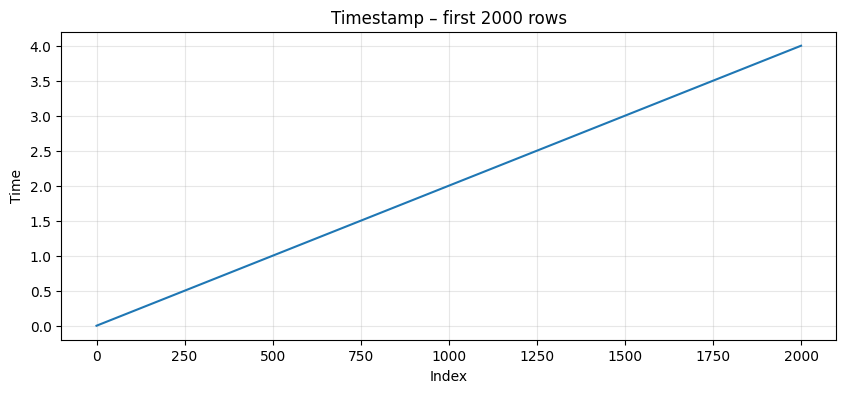

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = pd.read_csv("processed_step1/coordinates_time.csv", header=None).iloc[:, 0].values
dt = np.diff(t)

plt.figure(figsize=(10,4))
plt.plot(t[:2000])
plt.title("Timestamp – first 2000 rows")
plt.xlabel("Index")
plt.ylabel("Time")
plt.grid(True, alpha=0.3)
plt.show()



## Feature Distribution: Before vs After Scaling

This cell visualizes the effect of StandardScaler on individual features.

### Purpose

Compare the distribution of a single feature before and after Z-score normalization to verify that:
- The **shape** of the distribution is preserved (scaling does not alter the underlying data structure)
- The **location** is shifted to zero mean
- The **scale** is normalized to unit variance

### Interpretation

| Plot | X-axis | Expected Range |
|------|--------|----------------|
| Left (original) | Physical units (Å) | Dataset-dependent (e.g., 20-57 for coordinates) |
| Right (scaled) | Z-score (dimensionless) | Approximately -3 to +3 |

The distribution shape should be **identical** in both plots — only the axis scale changes. This confirms that StandardScaler correctly transforms the data without introducing distortions.

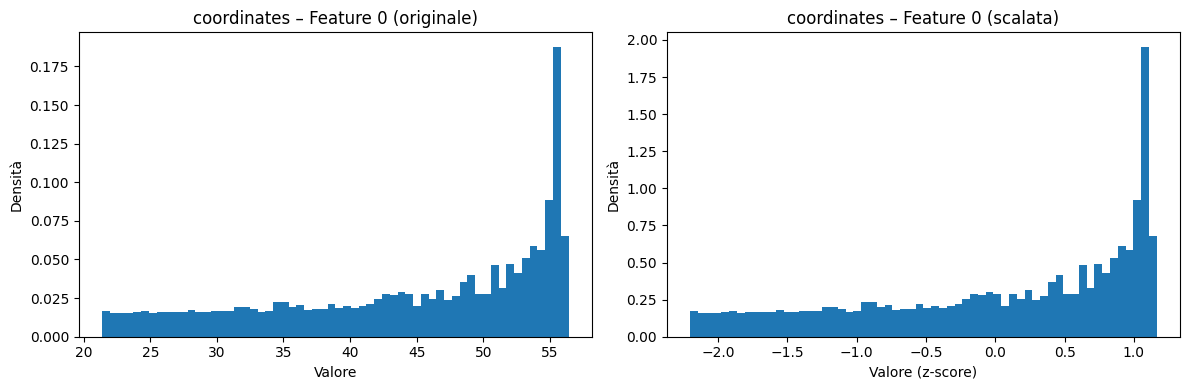

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_before_after(dataset, col_idx=0):
    clean = pd.read_csv(f"processed_step1/{dataset}_clean.csv")
    scaled = pd.read_csv(f"processed_step1/{dataset}_scaled.csv")

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(clean.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (original)")
    plt.xlabel("Valore")
    plt.ylabel("Densità")

    plt.subplot(1,2,2)
    plt.hist(scaled.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (scaled)")
    plt.xlabel("Value (z-score)")
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

plot_before_after("coordinates", 0)


## Temporal Evolution of a Single Feature

This cell visualizes the time-series behavior of an individual feature to verify data integrity.

### Purpose

Verify that the feature varies over time in a **continuous and physically plausible** manner, without:
- Sudden discontinuities or jumps
- Constant flat regions (which would indicate missing data)
- Artifacts introduced by preprocessing

### Expected Result

For **velocity** features, the plot should show:
- **Stochastic oscillations** around zero (characteristic of MD simulations at thermal equilibrium)
- **Continuous signal** with no abrupt jumps
- **Amplitude** consistent with typical atomic velocities

### Interpretation

A smooth, oscillating pattern confirms that:
1. The preprocessing did not introduce artifacts
2. The data correctly represents physical molecular dynamics
3. The feature is ready for sequence-based model training

**Note**: If this plot shows a straight diagonal line instead of oscillations, it indicates that the timestamp column was not correctly removed — this was the bug we fixed earlier in the preprocessing pipeline.

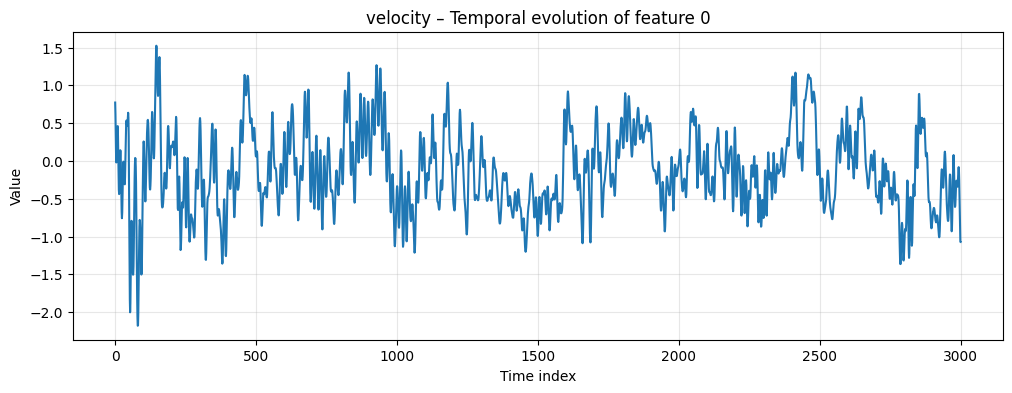

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_series(dataset, col_idx=0, n_points=3000):
    df = pd.read_csv(f"processed_step1/{dataset}_clean.csv")

    plt.figure(figsize=(12,4))
    plt.plot(df.iloc[:n_points, col_idx])
    plt.title(f"{dataset} – Temporal evolution of feature {col_idx}")
    plt.xlabel("Time index")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_time_series("velocity", 0)

## Scaled Feature Distributions by Dataset

This cell visualizes the overall distribution of standardized values for each dataset.

### Purpose

Compare the distribution shapes across the three physical quantities (coordinates, forces, velocity) to verify:
- Correct application of StandardScaler (all centered at zero)
- Preservation of the underlying physical characteristics
- Absence of outliers or anomalies introduced by preprocessing

### Physical Interpretation

| Dataset | Expected Distribution | Physical Reason |
|---------|----------------------|-----------------|
| **Coordinates** | Non-Gaussian, asymmetric | Atoms constrained by molecular structure (bonds, folding) |
| **Forces** | Quasi-Gaussian, heavy tails | Non-linear interactions with occasional force spikes |
| **Velocity** | Gaussian, symmetric | Maxwell-Boltzmann equilibrium statistics |

### Note on Sampling

A random sample of 50,000 values is drawn from each dataset to ensure efficient plotting while maintaining statistical representativeness. The dashed vertical line at x=0 confirms that all distributions are correctly centered after standardization.

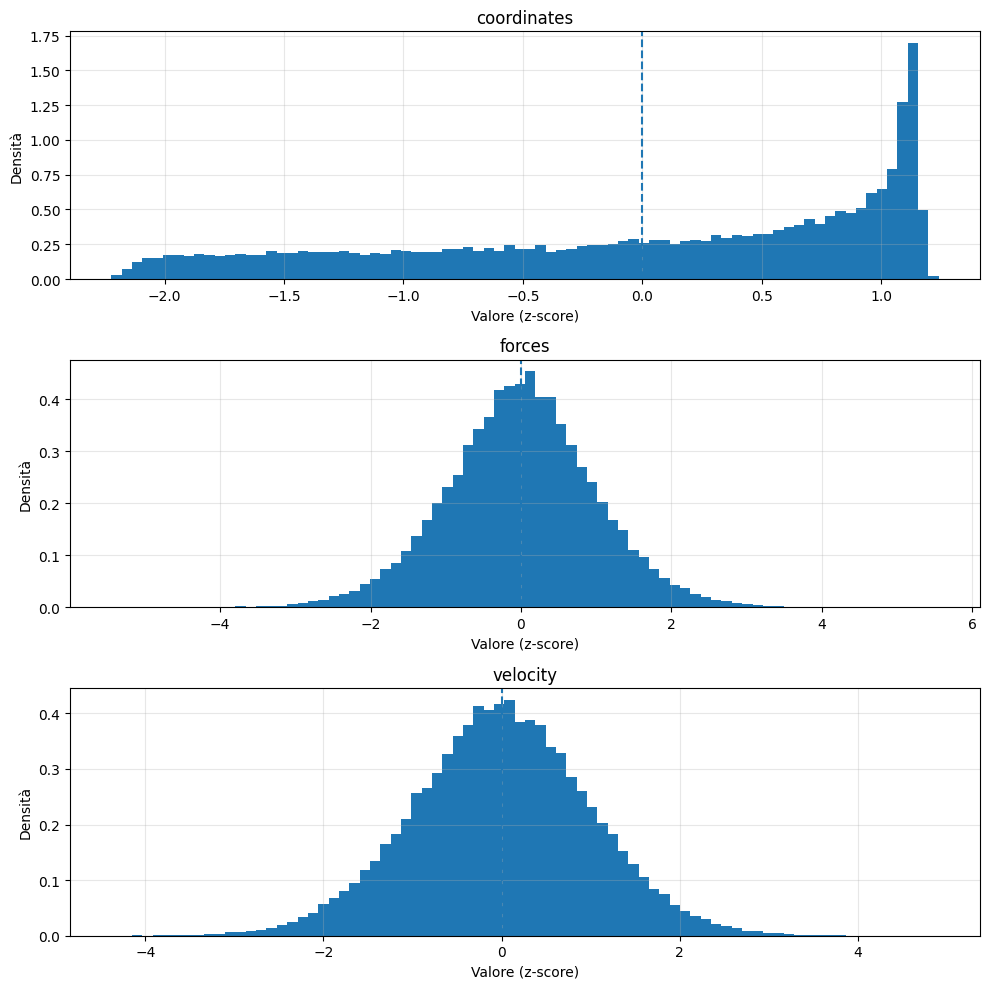

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = ["coordinates", "forces", "velocity"]

plt.figure(figsize=(10,10))

for i, d in enumerate(datasets, 1):
    df = pd.read_csv(f"processed_step1/{d}_scaled.csv")
    values = df.values.flatten()
    values = np.random.choice(values, size=50000, replace=False)

    plt.subplot(3, 1, i)
    plt.hist(values, bins=80, density=True)
    plt.axvline(0, linestyle="--")
    plt.title(f"{d}")
    plt.xlabel("Value (z-score)")
    plt.ylabel("Densità")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Physical Interpretation of Distributions

### Coordinates (Non-Gaussian)
The distribution of atomic coordinates is **non-Gaussian and asymmetric**, with a pronounced peak toward higher values. This is exactly what we expect: protein atoms are not free to move anywhere in space, but are **constrained by molecular structure** (covalent bonds, bond angles, protein folding). The peak indicates that many atoms occupy a preferred spatial region, consistent with the 3D conformation of the protein.

### Forces (Quasi-Gaussian)
The distribution of forces is **approximately Gaussian and symmetric**, centered at zero, but exhibits **heavier tails** compared to an ideal Gaussian. This reflects the physics of molecular interactions: most of the time forces are moderate, but occasionally **force spikes** occur due to close collisions, intense electrostatic repulsions, or geometric constraints. Heavy tails are typical of non-linear potentials (Lennard-Jones, Coulomb).

### Velocity (Gaussian)
The distribution of velocities is **Gaussian and symmetric**, perfectly centered at zero. This is the expected result from statistical mechanics: in an MD simulation at thermal equilibrium, the components of atomic velocities follow the **Maxwell-Boltzmann distribution**, which for each Cartesian component (vx, vy, vz) is a Gaussian. This confirms that the simulation has reached thermodynamic equilibrium.